# Big Data Concepts and Spark Architecture

## Approaches to speed up data processing

This course covers `PySpark` applications in data analysis. But before we dive into coding, let's discuss some Big Data basics and approaches to processing huge amounts of data. The table below compares the two main strategies for scaling your data infrastructure:

| Monolithic | Distributed |
|---|---|
| Upgrade the system with RAM, cores | Add systems (nodes) |
| Vertical scaling | Horizontal scaling |
| Availability | High availability |

However, monolithic systems have scaling limits. To overcome this, distributed computing is used. This approach is implemented in ecosystems like MapReduce, Hadoop, and Spark.

## MapReduce

`MapReduce` is a programming model for processing large datasets by splitting work into parallel map and reduce tasks, with an intermediate shuffle phase that groups data by keys. MapReduce was proposed by Google researchers Jeffrey Dean and Sanjay Ghemawat in a paper presented in December 2004. MapReduce includes three stages:

1. `Map` – preliminary processing of input data as a large list of values. The master node receives this list, splits it into parts and sends them to worker nodes. Each worker applies the Map function to its local data and writes results as key–value pairs to temporary storage.  
2. `Shuffle` – workers redistribute data based on the keys produced by Map, so that all data for the same key reside on a single worker.  
3. `Reduce` – each worker processes, in parallel, each group of data in key order and stitches results back to the master node. The master receives intermediate results from workers and assigns them to idle workers for the next step, and the final output after all steps is the solution to the original problem.

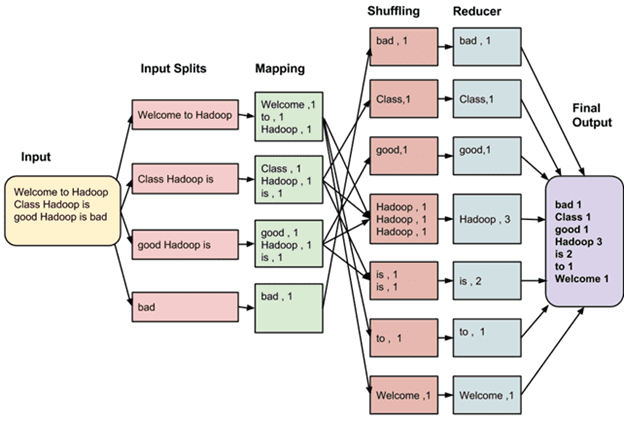

## Hadoop

`Hadoop` was created in 2006 in Java by Doug Cutting and Mike Cafarella. It was inspired by papers on MapReduce, and it's named after a toy elephant. Technically, Hadoop is a freely distributed set of utilities, libraries, and a framework for developing and running distributed programs on clusters of hundreds or thousands of nodes.

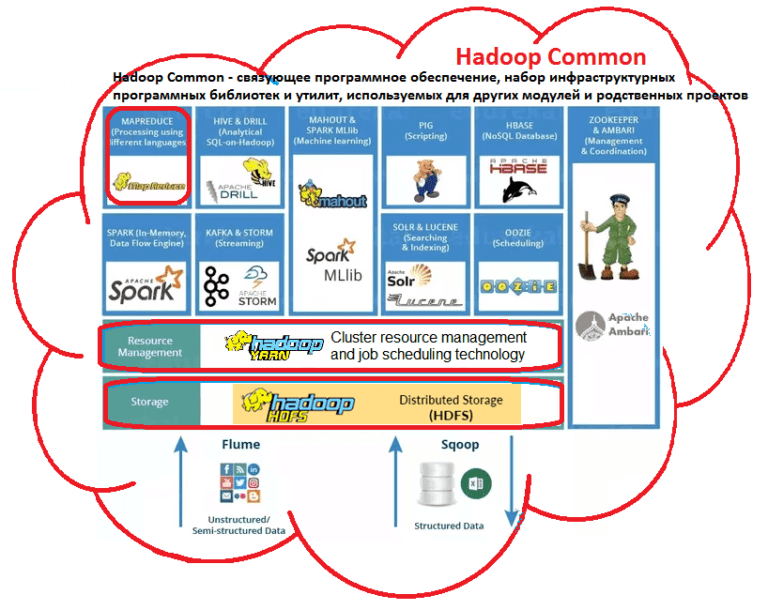

The project consists of four main modules:

- `Hadoop Common` is a set of infrastructural software libraries and utilities used by other solutions and related projects, in particular for managing distributed files and creating the required infrastructure.
- `HDFS` – the distributed file system, Hadoop Distributed File System – a technology for storing files on various data servers (nodes, DataNodes), whose addresses are held on a special name server (master, NameNode). HDFS provides reliable storage of large files that are blockwise distributed across the cluster’s compute nodes.
- `YARN` (Yet Another Resource Negotiator) is a job-scheduling and cluster-management system. Also called MapReduce 2.0, it is a set of system programs (daemons) that enable resource sharing, scalability, and reliable operation of distributed applications. YARN effectively serves as the interface between the cluster’s hardware resources and the applications that use its compute and data-processing capacity.
- `Hadoop MapReduce` is a programming and execution platform for distributed MapReduce computations, using a large number of computers that form a cluster.

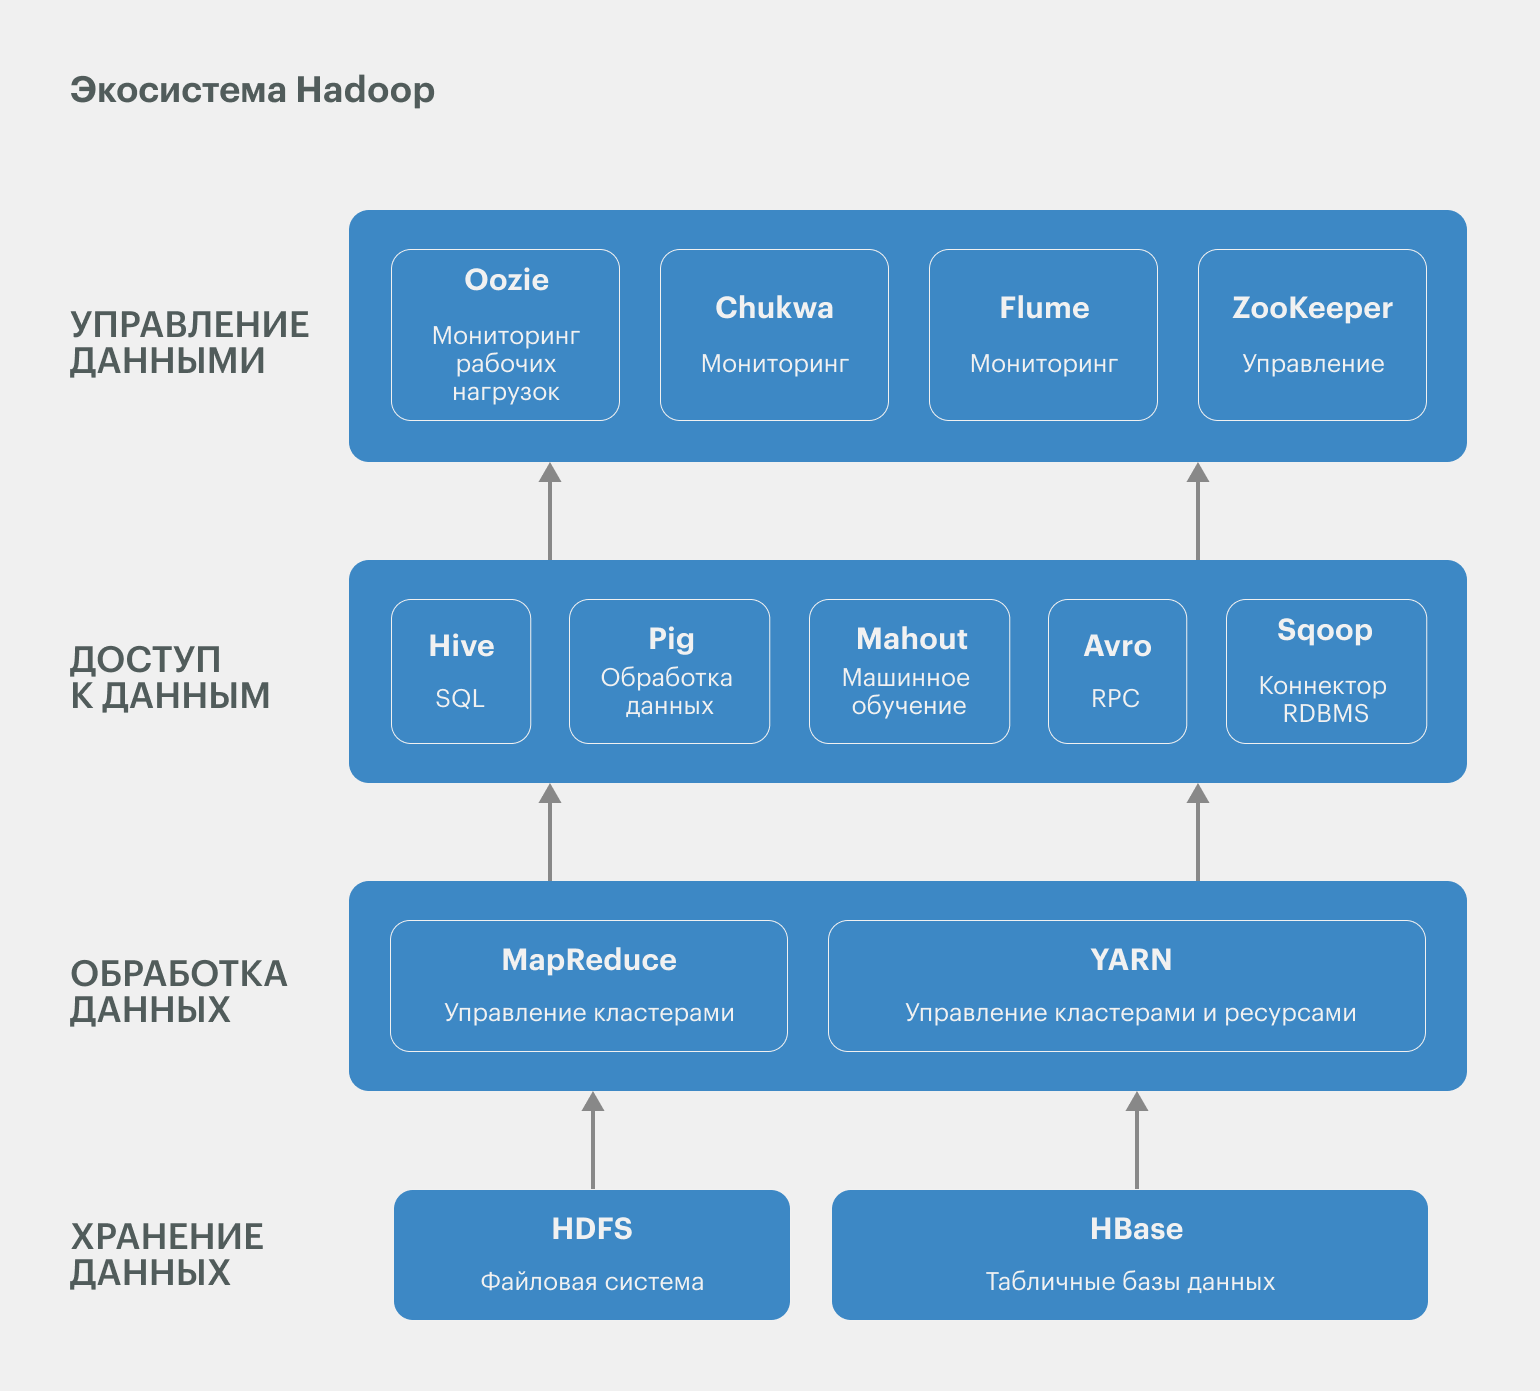

## Apache Spark architecture

In Spark architecture there are three responsibility layers: the resource manager, the driver, and the workers with their executors.  
1. The `resource manager` allocates cluster resources and launches containers or processes for applications, and it enforces isolation and scheduling policies.  
2. The `driver` is the application process that builds the execution plan as a DAG, splits it into tasks, and schedules those tasks on executors.  
3. `Workers` are machines that host executors, and an executor is a process on a worker that runs tasks, reads and writes data, caches intermediate datasets in memory, and reports status back to the driver.  

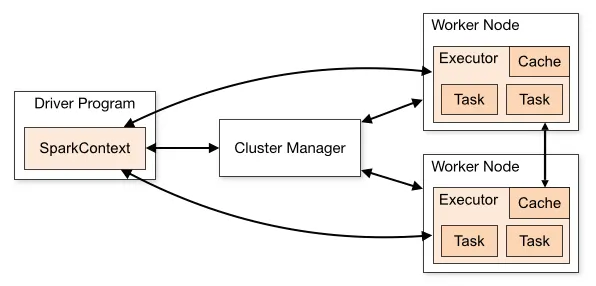

## Spark driver

Spark applications are coordinated by the `SparkContext` (or SparkSession) inside the main program, which is called the `driver`. The driver initializes SparkContext, controls the flow of jobs, schedules tasks, and remains available for the lifetime of the application. The driver must listen for and handle incoming calls from its executors for the entire lifecycle.

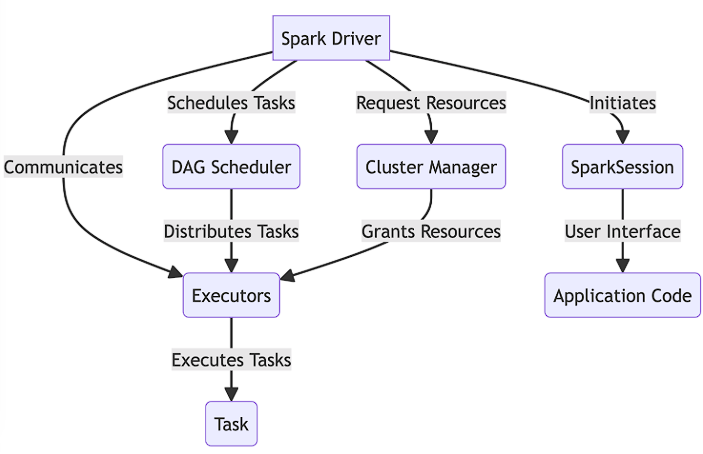

In operation the driver requests executors from the resource manager, the resource manager starts those executors on different workers, and the driver then sends tasks to the executors for execution. During shuffle executors exchange data directly, which reduces driver load, and cached data on executors speeds up iterative algorithms.  

If a worker fails, only the tasks and cached data on that worker are lost and the driver can reschedule the tasks elsewhere, while if the driver fails the whole application stops unless driver recovery or high availability is configured. If the resource manager fails or is overloaded, resource allocation for all applications suffers and new executors cannot be launched until it recovers.

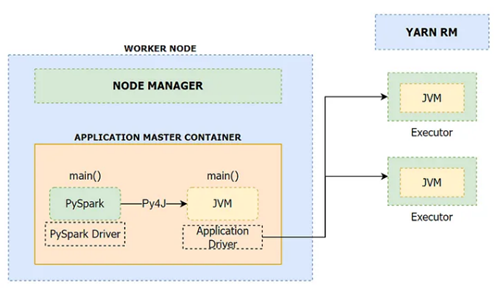

This is a PySpark driver. A Python process runs your Python code and uses Py4J over a TCP connection to call methods in the JVM. Py4J is the bridge that enables remote method calls and object transfer between Python and the JVM. The JVM hosts the main Spark driver and Spark Core, builds the DAG and talks to the ResourceManager and executors.

##YARN

YARN is a resource management framework for Apache Spark. At the core of YARN is the division of resource management between the ResourceManager and application-level ApplicationMasters. ResourceManager is the central YARN service that tracks all available resources in the cluster and makes decisions about allocating CPU and memory among applications. ApplicationMaster is the representative of a single application that negotiates with the ResourceManager.

The ResourceManager allocates resources among all applications. The NodeManager is the agent on a node responsible for containers, monitoring, resource usage (CPU, memory, network), and reporting all of that back to the ResourceManager. A Spark application holds resources for the duration of its execution. This differs from MapReduce, where resources are returned at the end of each task and reallocated at the start of the next task.

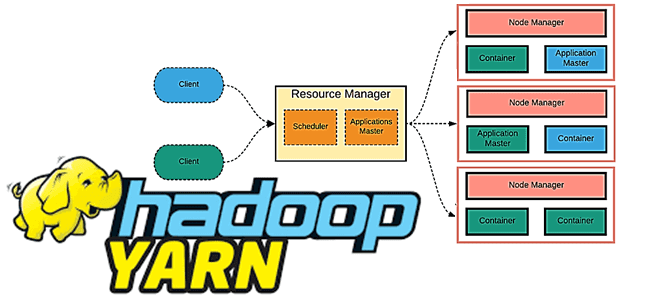

An application is what is submitted by the client to the scheduler in a YARN cluster. It can be a single job or a graph of jobs (DAG). A job is a Spark job, a Hive query, or any similar construct. The program that submits an application to YARN is called the YARN client. The placement of the driver relative to the client and the ApplicationMaster determines the deployment mode the Spark application runs in: client mode or cluster mode.

In client mode the driver runs on the YARN client side and is therefore not managed as part of the cluster. The client cannot exit until the application finishes.

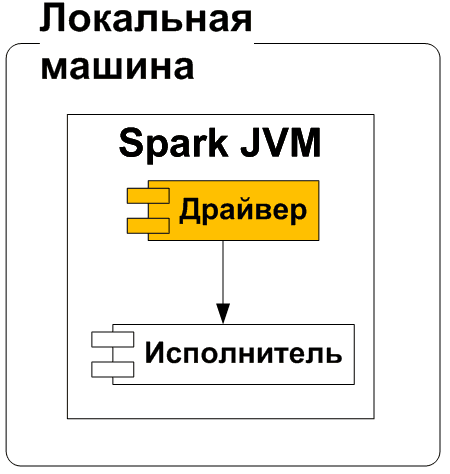

In cluster mode the driver runs inside the ApplicationMaster, which itself runs inside a container on the cluster. The YARN client only receives status from the ApplicationMaster and may exit after submitting the application.

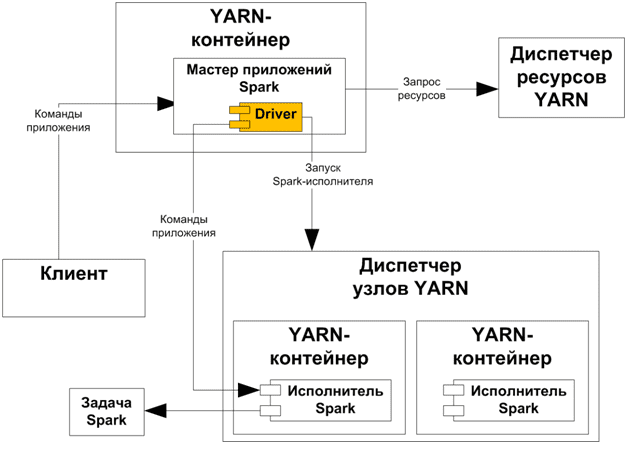

## Lazy evaluation

In Spark, calculations are done only if an action is called. For instance, an action might be printing the result to the console.

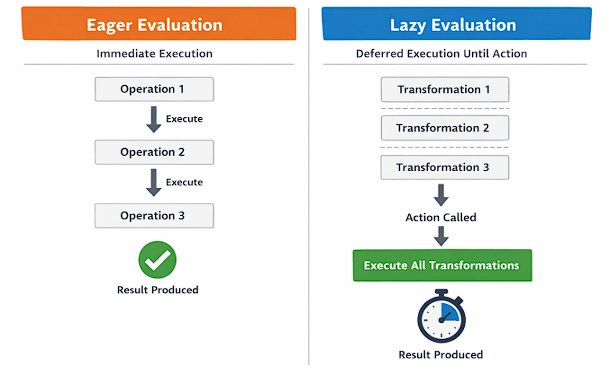

The order of computations is structured as `DAG` (Directed Acyclic Graph). It’s the sequence of steps Spark plans to execute your code. Spark builds the DAG to optimize the whole process before running anything, which is why it’s called lazy evaluation.



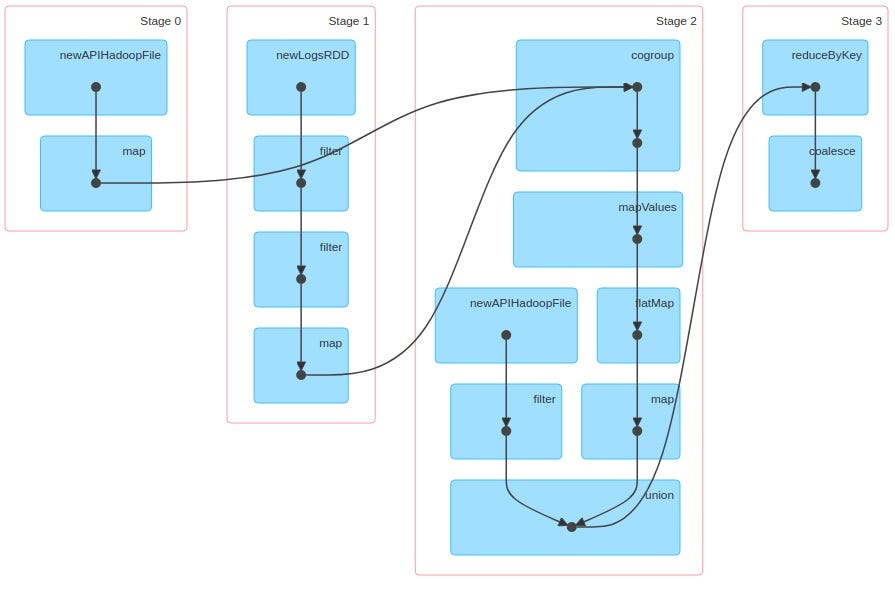

## Jobs, stages, and tasks

When a Spark application calls an action (for example, collect() or take()) on a DataFrame, it creates a job. A job is divided into one or more stages. Each stage consists of one or more tasks. A task runs on a single partition and is executed by one executor. An executor can run one or more tasks.

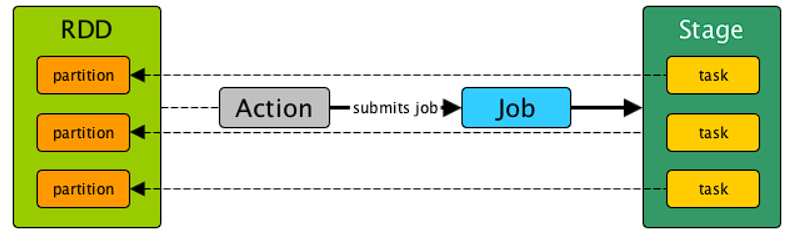

A task is the smallest unit of execution in Spark: it performs a sequence of operations (read, filter, map, etc.) on one partition. Many tasks that run the same operations form a stage, which enables parallel processing. Each task maps to one core and one partition.

Each job is represented as a directed acyclic graph (DAG) that contains one or more stages. Stages are determined by shuffle boundaries: operations that require data movement (shuffles) create stage boundaries. If a job has no shuffles, it typically has a single stage. Operations that trigger shuffles (for example, reduceByKey() or join()) produce new stages. Jobs are created whenever an action is executed For example, write().

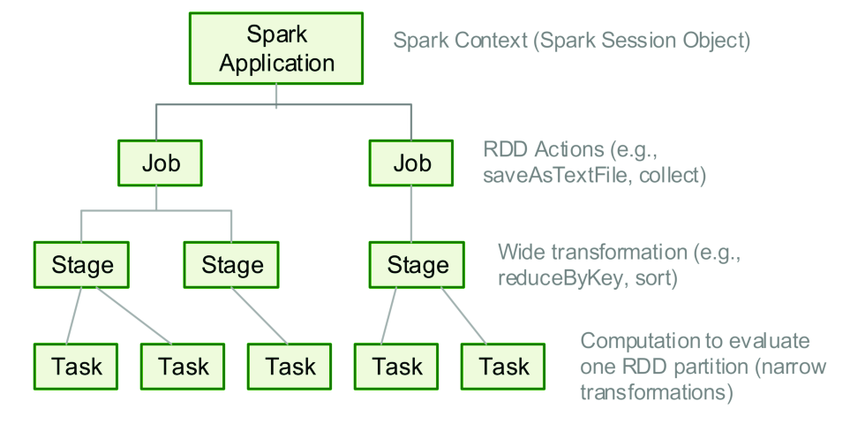

## Driver Memory Management

Driver Memory Management in Spark can be understood as several distinct memory areas with different responsibilities.

**JVM heap memory** is the main memory region inside the JVM where Java and Scala objects are stored. This includes Spark internal structures such as RDDs and DataFrames, DAG and execution metadata, as well as any cached data stored in heap. All of this memory is managed by the garbage collector.

**Overhead memory** is a pool of native memory reserved for the driver or executors. It includes thread stacks, JVM metaspace, native libraries, and also covers off-heap buffers. This memory is configured separately using parameters like `spark.driver.memoryOverhead` and is required to ensure stable execution beyond the JVM heap.

**Off-heap memory** is optional and allocated outside of the JVM heap. It is typically used for direct buffers such as DirectByteBuffer, Netty buffers, and JNI-based components. This memory is not controlled by the JVM garbage collector, which helps reduce GC pressure and improves performance for operations like network IO.

In PySpark, there is also optional **Python memory**, which is used by the separate Python process. It includes Python objects, UDFs, and serialized data exchanged between JVM and Python. This memory is logically independent from the JVM heap and needs to be considered separately when tuning applications.

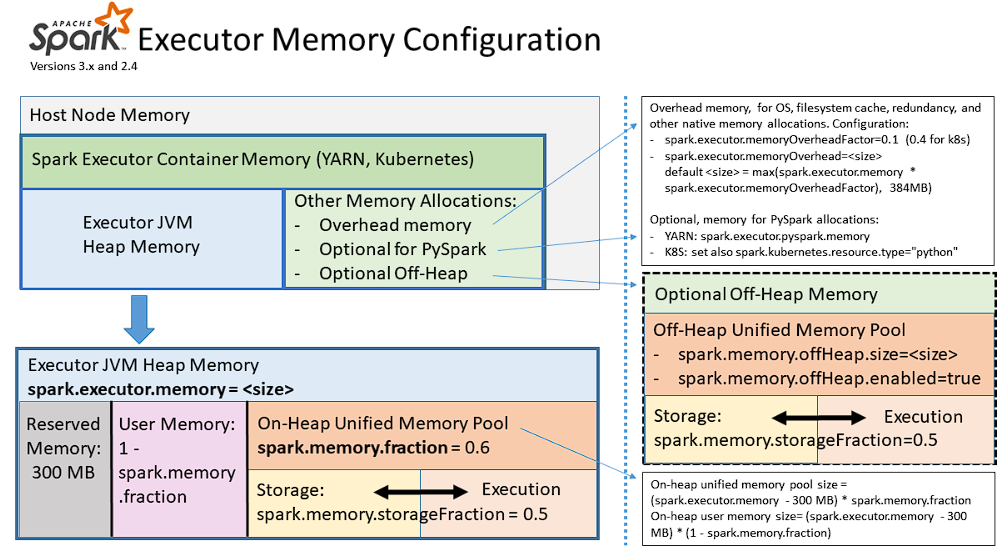


## Unified Memory Management

Spark uses a unified memory management model inside the JVM heap for executors. Instead of strictly separating memory for execution and storage, Spark allocates a single shared region and dynamically balances it between the two.

**Execution memory** is used for operations like joins, aggregations, and sorting. **Storage memory** is used for caching DataFrames and RDDs. In the unified model these two regions can borrow memory from each other. For example, if execution needs more memory for a large join, it can take space from storage. Conversely, if there is free space, it can be used to cache data.

When storage memory needs to free space, Spark evicts cached blocks using an LRU policy. This means least recently used blocks are removed first. Blocks that have not been accessed for the longest time are considered the best candidates for eviction. This allows Spark to keep frequently used data in memory while removing less useful data when memory pressure increases.

Execution memory, in contrast, is not evicted in the same way. If there is not enough memory for execution, Spark may spill data to disk. This makes unified memory flexible, but also means that inefficient memory usage can lead to spills or recomputation.


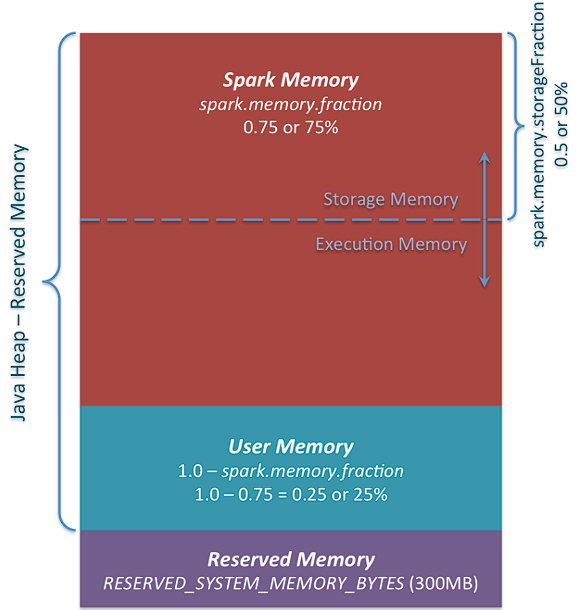